<a href="https://colab.research.google.com/github/chiamakachijioke/urban-mobility-optimisation/blob/main/notebooks/04_A_Star_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A * Shortest Path Algorithm**



This notebook implements the A* algorithm from scratch.

A* finds the shortest path between a starting node and a destination node in a weighted graph.

Unlike Dijkstra's algorithm, A* also uses a heuristic estimate of the remaining distance from each node to the destination.

## How A* works

A* considers two costs:

- `g(n)` is the actual cost from the starting node to the current node.
- `h(n)` is the estimated cost from the current node to the destination.

A* combines both values:

`f(n) = g(n) + h(n)`

The node with the smallest estimated total cost is explored first.

| Value  | Meaning                           |
| ------ | --------------------------------- |
| `g(n)` | Actual distance already travelled |
| `h(n)` | Estimated remaining distance      |
| `f(n)` | Estimated total journey distance  |


Dijkstra uses only:

`g(n)`

A* uses:

`g(n) + h(n)`

Suppose two nodes are waiting:
```
Node A:
g = 30
h = 50
f = 80
```
```
Node B:
g = 40
h = 20
f = 60
```
- Dijkstra would choose Node A because its actual distance, 30, is smaller.

- A* would choose Node B because its estimated total distance, 60, is smaller.

A* is therefore more goal-directed.

# **1. Import the librries**


In [ ]:
# Import the librries

import math
import heapq

import matplotlib.pyplot as plt
import networkx as nx

# **2. Recreate same data as others**

In [ ]:
# Recreate the location data

locations = {
    0: {"name": "Depot", "x": 50, "y": 50, "demand": 0},
    1: {"name": "Customer 1", "x": 20, "y": 30, "demand": 4},
    2: {"name": "Customer 2", "x": 80, "y": 25, "demand": 6},
    3: {"name": "Customer 3", "x": 15, "y": 75, "demand": 3},
    4: {"name": "Customer 4", "x": 65, "y": 80, "demand": 7},
    5: {"name": "Customer 5", "x": 40, "y": 20, "demand": 5},
    6: {"name": "Customer 6", "x": 90, "y": 60, "demand": 4},
    7: {"name": "Customer 7", "x": 30, "y": 90, "demand": 6},
    8: {"name": "Customer 8", "x": 70, "y": 45, "demand": 2},
    9: {"name": "Customer 9", "x": 45, "y": 70, "demand": 5},
}

## 3. Recreate the distance function


In [ ]:
# This is the straight-line distance between two locations.

def euclidean_distance(node_a, node_b, location_data):
    x1 = location_data[node_a]["x"]
    y1 = location_data[node_a]["y"]

    x2 = location_data[node_b]["x"]
    y2 = location_data[node_b]["y"]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 2)

This function has two purposes in this notebook:

- Calculating the weight of each road.
- Estimating the remaining distance to the destination.

## 4. Recreate the road connections


In [ ]:
# Each tuple represents one direct road.

connections = [
    (0, 1),
    (0, 8),
    (0, 9),

    (1, 3),
    (1, 5),

    (2, 5),
    (2, 6),
    (2, 8),

    (3, 7),
    (3, 9),

    (4, 6),
    (4, 7),
    (4, 8),
    (4, 9),

    (6, 8),

    (7, 9),

    (8, 9),
]

## 5. Recreate an adjacency list


In [ ]:
# An adjacency list stores the neighbours of every node.

graph = {
    node: {}
    for node in locations
}

# Every node exists, but no neighbours have been added yet.
# Now to add the roads:

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    graph[node_a][node_b] = road_distance
    graph[node_b][node_a] = road_distance


In [ ]:
# Check it

for node, neighbours in graph.items():
    print(f"Node {node}: {neighbours}")

Node 0: {1: 36.06, 8: 20.62, 9: 20.62}
Node 1: {0: 36.06, 3: 45.28, 5: 22.36}
Node 2: {5: 40.31, 6: 36.4, 8: 22.36}
Node 3: {1: 45.28, 7: 21.21, 9: 30.41}
Node 4: {6: 32.02, 7: 36.4, 8: 35.36, 9: 22.36}
Node 5: {1: 22.36, 2: 40.31}
Node 6: {2: 36.4, 4: 32.02, 8: 25.0}
Node 7: {3: 21.21, 4: 36.4, 9: 25.0}
Node 8: {0: 20.62, 2: 22.36, 4: 35.36, 6: 25.0, 9: 35.36}
Node 9: {0: 20.62, 3: 30.41, 4: 22.36, 7: 25.0, 8: 35.36}


# **6. Create the heuristic function**

In [ ]:
# create h(n). The heuristic estimates the distance from the current node to the destination using straight-line distance.

def heuristic(
    current_node,
    destination_node,
    location_data
):
    return euclidean_distance(
        current_node,
        destination_node,
        location_data
    )

In [ ]:
# Testing:

estimated_distance = heuristic(
    1,
    6,
    locations
)

print(
    "Estimated distance from node 1 to node 6:",
    estimated_distance
)

Estimated distance from node 1 to node 6: 76.16


This does not necessarily represent an actual valid road route.

It only estimates how close `node 1` is to `node 6`.

For example, there may be no direct road:

`1 → 6`

but the straight-line distance still gives `A*` an idea of the direction of the destination.

#7. Understand an admissible heuristic


## Admissible heuristic

For `A*` to guarantee the shortest path, the heuristic should not overestimate the true remaining cost.

A heuristic that never overestimates is called `admissible`.

Euclidean distance is suitable here because the straight-line distance between two nodes cannot be greater than the distance of a route that travels through several roads between them.

In simple terms:

The estimated distance should be optimistic, not exaggerated.

For example, suppose the actual shortest route from `node 1` to `node 6` costs:

`81.68`

A heuristic estimate such as:

`70`

is acceptable.

An estimate such as:

`100`

would overestimate the actual cost and could cause A* to miss the optimal path.

# **8. Create the A * function**

In [ ]:
def a_star(
    graph_data,
    location_data,
    start_node,
    destination_node
):
    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    actual_distances = {
        node: math.inf
        for node in graph_data
    }

    estimated_total_distances = {
        node: math.inf
        for node in graph_data
    }

    predecessors = {
        node: None
        for node in graph_data
    }

    actual_distances[start_node] = 0

    estimated_total_distances[start_node] = heuristic(
        start_node,
        destination_node,
        location_data
    )

    unvisited_queue = [
        (
            estimated_total_distances[start_node],
            start_node
        )
    ]

    visited_nodes = set()

    while unvisited_queue:
        current_estimated_total, current_node = (
            heapq.heappop(unvisited_queue)
        )

        if current_node in visited_nodes:
            continue

        visited_nodes.add(current_node)

        if current_node == destination_node:
            break

        for neighbour, edge_weight in graph_data[
            current_node
        ].items():

            new_actual_distance = (
                actual_distances[current_node]
                + edge_weight
            )

            if (
                new_actual_distance
                < actual_distances[neighbour]
            ):
                actual_distances[neighbour] = (
                    new_actual_distance
                )

                predecessors[neighbour] = current_node

                remaining_estimate = heuristic(
                    neighbour,
                    destination_node,
                    location_data
                )

                new_estimated_total = (
                    new_actual_distance
                    + remaining_estimate
                )

                estimated_total_distances[neighbour] = (
                    new_estimated_total
                )

                heapq.heappush(
                    unvisited_queue,
                    (
                        new_estimated_total,
                        neighbour
                    )
                )

    return (
        actual_distances,
        estimated_total_distances,
        predecessors,
        visited_nodes
    )

# **9. Understanding the variables**

- `Dijkstra` used: `distances`

- `A*` uses two different dictionaries.

`actual_distances` stores: **`g(n)`**

It is the actual cost from the starting node to each node.

For example:

`actual_distances[8] = 56.68`

means the best known route from the *starting node* to *node 8* costs `56.68`.

`estimated_total_distances` stores: **`f(n) = g(n) + h(n)`**

For example:

`Actual distance to node 8 = 56.68`

`Estimated distance` from *node 8 to destination* = `25.00`

Therefore:
```
Estimated total = 56.68 + 25.00
                = 81.68
```
`A*` uses this estimated total to decide which node to explore first.

---
---
---

## Understand the starting values

At the beginning:

`actual_distances[start_node] = 0`

because the actual distance from the starting node to itself is zero.

Then:
```
estimated_total_distances[start_node] = heuristic(
    start_node,
    destination_node,
    location_data
)
```
This means:

`f(start) = 0 + estimated distance to destination`

---
---
---

## Understand the A* queue

The queue stores:
```
(
    estimated_total_distance,
    node
)
```
This is different from Dijkstra.

*Dijkstra stored:*
```
(
    actual_distance,
    node
)
```
*A * stores:*
```
(
    actual_distance + heuristic,
    node
)
```
Therefore, the queue is ordered using `f(n)`, not only `g(n)`.

---
---
## Understand the relaxation step

This part is similar to Dijkstra:
```
new_actual_distance = (
    actual_distances[current_node]
    + edge_weight
)
```
It calculates the actual cost of reaching the neighbour through the current node.

Then:
```
if new_actual_distance < actual_distances[neighbour]:
```
checks whether the newly discovered route is better.

When it is better, A* updates:
```
actual_distances[neighbour]
predecessors[neighbour]
```
Then it calculates the heuristic:
```
remaining_estimate = heuristic(
    neighbour,
    destination_node,
    location_data
)
```
Finally:
```
new_estimated_total = (
    new_actual_distance
    + remaining_estimate
)
```
This is:

`f(n) = g(n) + h(n)`

# **10. Recreate the path reconstruction function**

In [ ]:
# Same used in Dijkstra notebook

def reconstruct_path(
    predecessors,
    start_node,
    destination_node
):
    path = []
    current_node = destination_node

    while current_node is not None:
        path.append(current_node)

        if current_node == start_node:
            break

        current_node = predecessors[current_node]

    path.reverse()

    if not path or path[0] != start_node:
        return None

    return path

# **11. Run A***

In [ ]:
# Using same example

start_node = 1
destination_node = 6

(
    actual_distances,
    estimated_total_distances,
    predecessors,
    visited_nodes
) = a_star(
    graph,
    locations,
    start_node,
    destination_node
)

In [ ]:
# Reconstruct the path:

shortest_path = reconstruct_path(
    predecessors,
    start_node,
    destination_node
)

print("Shortest path:", shortest_path)

print(
    "Shortest path cost:",
    round(
        actual_distances[destination_node],
        2
    )
)

print("Visited nodes:", visited_nodes)

print(
    "Number of visited nodes:",
    len(visited_nodes)
)

Shortest path: [1, 0, 8, 6]
Shortest path cost: 81.68
Visited nodes: {0, 1, 8, 6}
Number of visited nodes: 4


# **12. Inspect the A * values**

In [ ]:
for node in graph:
    actual = actual_distances[node]
    estimated_total = estimated_total_distances[node]

    print(f"Node {node}")

    if actual == math.inf:
        print("  Actual distance: infinity")
    else:
        print(
            "  Actual distance:",
            round(actual, 2)
        )

    if estimated_total == math.inf:
        print("  Estimated total: infinity")
    else:
        print(
            "  Estimated total:",
            round(estimated_total, 2)
        )

    print()

Node 0
  Actual distance: 36.06
  Estimated total: 77.29

Node 1
  Actual distance: 0
  Estimated total: 76.16

Node 2
  Actual distance: 79.04
  Estimated total: 115.44

Node 3
  Actual distance: 45.28
  Estimated total: 121.77

Node 4
  Actual distance: 92.04
  Estimated total: 124.06

Node 5
  Actual distance: 22.36
  Estimated total: 86.39

Node 6
  Actual distance: 81.68
  Estimated total: 81.68

Node 7
  Actual distance: infinity
  Estimated total: infinity

Node 8
  Actual distance: 56.68
  Estimated total: 81.68

Node 9
  Actual distance: 56.68
  Estimated total: 102.78



# **13. Create a cleaner A * output function**

In [ ]:
def find_a_star_path(
    graph_data,
    location_data,
    start_node,
    destination_node
):
    (
        actual_distances,
        estimated_total_distances,
        predecessors,
        visited_nodes
    ) = a_star(
        graph_data,
        location_data,
        start_node,
        destination_node
    )

    path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if path is None:
        return {
            "path": None,
            "cost": math.inf,
            "visited_nodes": visited_nodes
        }

    return {
        "path": path,
        "cost": round(
            actual_distances[destination_node],
            2
        ),
        "visited_nodes": visited_nodes
    }

In [ ]:
# Testing:

a_star_result = find_a_star_path(
    graph,
    locations,
    1,
    6
)

print(
    "A* path:",
    a_star_result["path"]
)

print(
    "A* cost:",
    a_star_result["cost"]
)

print(
    "A* visited nodes:",
    a_star_result["visited_nodes"]
)

A* path: [1, 0, 8, 6]
A* cost: 81.68
A* visited nodes: {0, 1, 8, 6}


# **14. Add your Dijkstra function for comparison**

In [ ]:
# Import dijkstra function

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import sys

module_folder = (
    "/content/drive/MyDrive/"
    "PhD_Optimisation_Code/modules"
)

if module_folder not in sys.path:
    sys.path.append(module_folder)

In [ ]:
from shortest_path_algorithms import find_dijkstra_path

# **15. Compare Dijkstra and A***

In [ ]:
dijkstra_result = find_dijkstra_path(
    graph,
    1,
    6
)

a_star_result = find_a_star_path(
    graph,
    locations,
    1,
    6
)

print("DIJKSTRA")
print("Path:", dijkstra_result["path"])
print("Cost:", dijkstra_result["cost"])
print(
    "Visited nodes:",
    dijkstra_result["visited_nodes"]
)
print(
    "Number visited:",
    len(dijkstra_result["visited_nodes"])
)

print()

print("A*")
print("Path:", a_star_result["path"])
print("Cost:", a_star_result["cost"])
print(
    "Visited nodes:",
    a_star_result["visited_nodes"]
)
print(
    "Number visited:",
    len(a_star_result["visited_nodes"])
)

DIJKSTRA
Path: [1, 0, 8, 6]
Cost: 81.68
Visited nodes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Number visited: 10

A*
Path: [1, 0, 8, 6]
Cost: 81.68
Visited nodes: {0, 1, 8, 6}
Number visited: 4


I check these things:

- Did both return the same path? => `Yes`
- Did both return the same cost? => `Yes`
- Did A* visit fewer nodes? => `Yes`

On a very small graph, they may visit the same or nearly the same number of nodes.

That does not mean A* is incorrect.

The difference becomes clearer on a much larger graph where there are many possible directions to explore.

# **16. Compare several journeys**

In [ ]:
test_pairs = [
    (1, 6),
    (3, 2),
    (5, 7),
    (1, 4),
    (7, 2),
]

In [ ]:
for start, destination in test_pairs:
    dijkstra_result = find_dijkstra_path(
        graph,
        start,
        destination
    )

    a_star_result = find_a_star_path(
        graph,
        locations,
        start,
        destination
    )

    print(
        f"Journey: {start} → {destination}"
    )

    print(
        "Dijkstra path:",
        dijkstra_result["path"]
    )

    print(
        "Dijkstra cost:",
        dijkstra_result["cost"]
    )

    print(
        "Dijkstra visited:",
        len(
            dijkstra_result["visited_nodes"]
        )
    )

    print(
        "A* path:",
        a_star_result["path"]
    )

    print(
        "A* cost:",
        a_star_result["cost"]
    )

    print(
        "A* visited:",
        len(
            a_star_result["visited_nodes"]
        )
    )

    print("-" * 40)

Journey: 1 → 6
Dijkstra path: [1, 0, 8, 6]
Dijkstra cost: 81.68
Dijkstra visited: 10
A* path: [1, 0, 8, 6]
A* cost: 81.68
A* visited: 4
----------------------------------------
Journey: 3 → 2
Dijkstra path: [3, 9, 8, 2]
Dijkstra cost: 88.13
Dijkstra visited: 10
A* path: [3, 9, 8, 2]
A* cost: 88.13
A* visited: 4
----------------------------------------
Journey: 5 → 7
Dijkstra path: [5, 1, 3, 7]
Dijkstra cost: 88.85
Dijkstra visited: 9
A* path: [5, 1, 3, 7]
A* cost: 88.85
A* visited: 4
----------------------------------------
Journey: 1 → 4
Dijkstra path: [1, 0, 9, 4]
Dijkstra cost: 79.04
Dijkstra visited: 9
A* path: [1, 0, 9, 4]
A* cost: 79.04
A* visited: 4
----------------------------------------
Journey: 7 → 2
Dijkstra path: [7, 9, 8, 2]
Dijkstra cost: 82.72
Dijkstra visited: 9
A* path: [7, 9, 8, 2]
A* cost: 82.72
A* visited: 4
----------------------------------------


# **17. Verify A * using NetworkX**

In [ ]:
# Build the NetworkX graph:

transport_graph = nx.Graph()

for node, data in locations.items():
    transport_graph.add_node(
        node,
        pos=(data["x"], data["y"])
    )

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    transport_graph.add_edge(
        node_a,
        node_b,
        weight=road_distance
    )

In [ ]:
# Create a NetworkX-compatible heuristic:

def networkx_heuristic(node_a, node_b):
    return euclidean_distance(
        node_a,
        node_b,
        locations
    )

In [ ]:
# Verifying:

networkx_a_star_path = nx.astar_path(
    transport_graph,
    source=1,
    target=6,
    heuristic=networkx_heuristic,
    weight="weight"
)

networkx_a_star_cost = nx.astar_path_length(
    transport_graph,
    source=1,
    target=6,
    heuristic=networkx_heuristic,
    weight="weight"
)

print(
    "NetworkX A* path:",
    networkx_a_star_path
)

print(
    "NetworkX A* cost:",
    round(networkx_a_star_cost, 2)
)

NetworkX A* path: [1, 0, 8, 6]
NetworkX A* cost: 81.68


# **18. Visualise the A * path**

In [ ]:
def plot_path(
    network,
    location_data,
    path,
    title
):
    positions = {
        node: (
            data["x"],
            data["y"]
        )
        for node, data in location_data.items()
    }

    path_edges = list(
        zip(
            path[:-1],
            path[1:]
        )
    )

    plt.figure(figsize=(10, 8))

    nx.draw(
        network,
        pos=positions,
        with_labels=True,
        node_size=900,
        font_size=11
    )

    nx.draw_networkx_edges(
        network,
        pos=positions,
        edgelist=path_edges,
        width=4
    )

    edge_labels = nx.get_edge_attributes(
        network,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        network,
        pos=positions,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(title)
    plt.show()

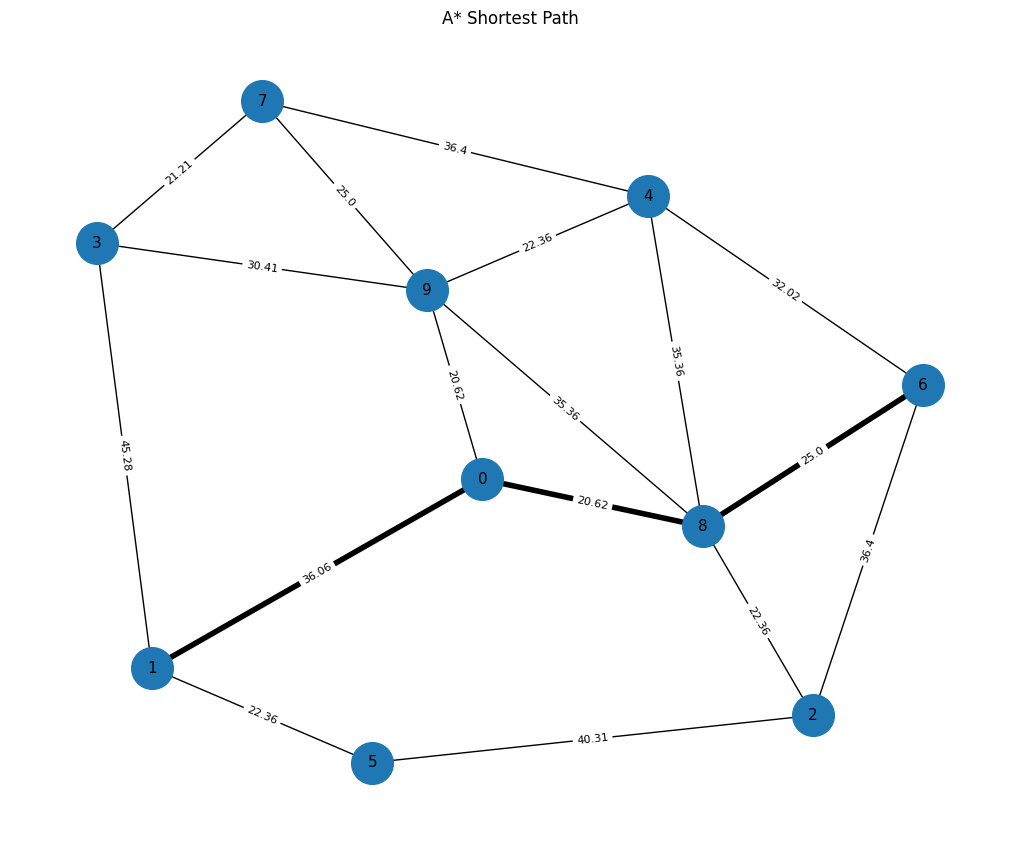

In [ ]:
a_star_result = find_a_star_path(
    graph,
    locations,
    1,
    6
)

plot_path(
    transport_graph,
    locations,
    a_star_result["path"],
    "A* Shortest Path"
)

# **19. Important relationship between Dijkstra and A***

## Relationship between Dijkstra and A*

Dijkstra and A* both find shortest paths in weighted graphs.

Dijkstra selects nodes using only the actual distance travelled.

A* selects nodes using the actual distance travelled plus an estimated remaining distance.

If the A* heuristic is always zero, A* behaves like Dijkstra.

# **20. Main differences**

| Feature                                          | Dijkstra                     | A*                             |
| ------------------------------------------------ | ---------------------------- | ------------------------------ |
| Uses actual distance                             | Yes                          | Yes                            |
| Uses estimated remaining distance                | No                           | Yes                            |
| Goal-directed                                    | No                           | Yes                            |
| Requires non-negative edge weights               | Yes                          | Yes                            |
| Can guarantee shortest path                      | Yes                          | Yes, with a suitable heuristic |
| Searches from start                              | In every promising direction | More towards the destination   |
| Needs coordinates or other heuristic information | No                           | Usually yes                    |


# **21. Important limitation of A***

## Limitations of A*

A* depends on the quality of its heuristic.

A weak heuristic may cause A* to behave almost like Dijkstra.

A heuristic that overestimates the remaining cost may prevent A* from guaranteeing the optimal path.

A* also requires extra information that can be used to estimate the remaining distance.

# **21. What A * does not solve**


## What A* does not solve

A* finds a shortest path between one starting location and one destination.

It does not decide the order for visiting every customer.

It does not assign customers to vehicles.

It does not handle vehicle capacity by itself.

Therefore, like Dijkstra, A* does not solve the full vehicle-routing problem.

# **22. Final notes**

## What I learned

- A* is a shortest-path algorithm.
- A* uses both the actual travelled cost and the estimated remaining cost.
- `g(n)` is the actual cost from the start to node `n`.
- `h(n)` is the estimated cost from node `n` to the destination.
- `f(n) = g(n) + h(n)`.
- A* explores the node with the smallest estimated total cost.
- Euclidean distance can be used as the heuristic when coordinates are available.
- A suitable heuristic should not overestimate the true remaining cost.
- Dijkstra is equivalent to A* when the heuristic is zero.
- Both algorithms may find the same shortest path, but A* can explore fewer nodes.

The central difference in my code is:

### **Dijkstra**
```
heapq.heappush(
    unvisited_queue,
    (new_distance, neighbour)
)
```
***versus:***

### **A***

```
heapq.heappush(
    unvisited_queue,
    (
        new_actual_distance
        + remaining_estimate,
        neighbour
    )
)
```
- Dijkstra prioritises the node with the smallest distance already travelled.

- A* prioritises the node with the smallest estimated complete journey.

# **23. Save reusable A * functions**

Mount Google Drive and create the folder

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

module_folder = (
    "/content/drive/MyDrive/"
    "Phd Optimization Code/modules"
)

os.makedirs(module_folder, exist_ok=True)

print("Module folder:", module_folder)

##### `%%writefile -a` must be the first line. The `-a` means append, so it adds A* without deleting Dijkstra.

In [ ]:
%%writefile -a /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py


# =========================================================
# A* HEURISTIC
# =========================================================

def euclidean_heuristic(
    current_node,
    destination_node,
    location_data
):
    """
    Estimate the remaining distance from the current node
    to the destination using Euclidean straight-line distance.
    """

    if current_node not in location_data:
        raise ValueError(
            f"Node {current_node} is missing from the location data."
        )

    if destination_node not in location_data:
        raise ValueError(
            f"Node {destination_node} is missing from the location data."
        )

    x1 = location_data[current_node]["x"]
    y1 = location_data[current_node]["y"]

    x2 = location_data[destination_node]["x"]
    y2 = location_data[destination_node]["y"]

    estimated_distance = math.sqrt(
        (x2 - x1) ** 2
        + (y2 - y1) ** 2
    )

    return round(estimated_distance, 2)


# =========================================================
# A* ALGORITHM
# =========================================================

def a_star(
    graph_data,
    location_data,
    start_node,
    destination_node
):
    """
    Find the shortest path information between two nodes
    using the A* algorithm.
    """

    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    actual_distances = {
        node: math.inf
        for node in graph_data
    }

    estimated_total_distances = {
        node: math.inf
        for node in graph_data
    }

    predecessors = {
        node: None
        for node in graph_data
    }

    actual_distances[start_node] = 0

    starting_estimate = euclidean_heuristic(
        start_node,
        destination_node,
        location_data
    )

    estimated_total_distances[start_node] = (
        starting_estimate
    )

    unvisited_queue = [
        (
            starting_estimate,
            start_node
        )
    ]

    visited_nodes = set()

    while unvisited_queue:
        (
            current_estimated_total,
            current_node
        ) = heapq.heappop(
            unvisited_queue
        )

        if current_node in visited_nodes:
            continue

        visited_nodes.add(current_node)

        if current_node == destination_node:
            break

        for neighbour, edge_weight in graph_data[
            current_node
        ].items():

            new_actual_distance = (
                actual_distances[current_node]
                + edge_weight
            )

            if (
                new_actual_distance
                < actual_distances[neighbour]
            ):
                actual_distances[neighbour] = (
                    new_actual_distance
                )

                predecessors[neighbour] = current_node

                remaining_estimate = euclidean_heuristic(
                    neighbour,
                    destination_node,
                    location_data
                )

                new_estimated_total = (
                    new_actual_distance
                    + remaining_estimate
                )

                estimated_total_distances[neighbour] = (
                    new_estimated_total
                )

                heapq.heappush(
                    unvisited_queue,
                    (
                        new_estimated_total,
                        neighbour
                    )
                )

    return (
        actual_distances,
        estimated_total_distances,
        predecessors,
        visited_nodes
    )


# =========================================================
# CLEAN A* OUTPUT FUNCTION
# =========================================================

def find_a_star_path(
    graph_data,
    location_data,
    start_node,
    destination_node
):
    """
    Return the A* shortest path, cost and visited nodes
    in a clean dictionary.
    """

    (
        actual_distances,
        estimated_total_distances,
        predecessors,
        visited_nodes
    ) = a_star(
        graph_data,
        location_data,
        start_node,
        destination_node
    )

    path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if path is None:
        return {
            "path": None,
            "cost": math.inf,
            "visited_nodes": visited_nodes
        }

    return {
        "path": path,
        "cost": round(
            actual_distances[destination_node],
            2
        ),
        "visited_nodes": visited_nodes
    }



Appending to /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py


# **24. Reload the updated module**

In [ ]:
import sys
import importlib

module_folder = (
    "/content/drive/MyDrive/"
    "PhD_Optimisation_Code/modules"
)

if module_folder not in sys.path:
    sys.path.append(module_folder)

import shortest_path_algorithms

importlib.reload(shortest_path_algorithms)

print("The shortest-path module has been updated.")

The shortest-path module has been updated.


# **25. Import both reusable functions**

In [ ]:
from shortest_path_algorithms import (
    find_dijkstra_path,
    find_a_star_path
)

print("Reusable Dijkstra and A* functions imported successfully.")

Reusable Dijkstra and A* functions imported successfully.


# **26. Test the saved A * function**

In [ ]:
a_star_test_result = find_a_star_path(
    graph,
    locations,
    1,
    6
)

print("A* path:", a_star_test_result["path"])
print("A* cost:", a_star_test_result["cost"])
print(
    "A* visited nodes:",
    a_star_test_result["visited_nodes"]
)
print(
    "Number visited:",
    len(a_star_test_result["visited_nodes"])
)

A* path: [1, 0, 8, 6]
A* cost: 81.68
A* visited nodes: {0, 1, 8, 6}
Number visited: 4


# **27. Confirm both algorithms remain available**

In [ ]:
dijkstra_test_result = find_dijkstra_path(
    graph,
    1,
    6
)

a_star_test_result = find_a_star_path(
    graph,
    locations,
    1,
    6
)

print("Dijkstra:", dijkstra_test_result)
print("A*:", a_star_test_result)

Dijkstra: {'path': [1, 0, 8, 6], 'cost': 81.68, 'visited_nodes': {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}}
A*: {'path': [1, 0, 8, 6], 'cost': 81.68, 'visited_nodes': {0, 1, 8, 6}}
